# GenerateCT inference smoke (low-res + super-res)

Scratchpad mirror of `src/inference.py` / `configs/inference.yaml` for visual sanity checks.

- Cell 1: 128³ low-res via `GenerateCTAdapter.inference()`
- Cell 2: save NIfTI + axial/coronal/sagittal mid-slice plots
- Cell 3: super-resolution to 512×512×201 (slower, optional)

Hydra-driven equivalent: `CUDA_VISIBLE_DEVICES=0 python src/inference.py`


In [1]:
import torch

# ── GPU 선택 ───────────────────────────────────────────────
GPU_ID = 0   # ← 0, 1, 2 중 원하는 GPU 번호로 바꾸세요
# ──────────────────────────────────────────────────────────

assert torch.cuda.is_available(), "CUDA를 사용할 수 없습니다."
assert GPU_ID < torch.cuda.device_count(), (
    f"GPU {GPU_ID}가 없습니다. 사용 가능한 GPU: {list(range(torch.cuda.device_count()))}"
)
DEVICE = f"cuda:{GPU_ID}"
print(f"사용 GPU: {DEVICE} — {torch.cuda.get_device_name(GPU_ID)}")

사용 GPU: cuda:0 — NVIDIA RTX PRO 6000 Blackwell Server Edition


In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from src.baselines.generatect_adapter import GenerateCTAdapter

adapter = GenerateCTAdapter(device_str=DEVICE, load_super_resolution=False)
prompt = "Findings consistent with viral pneumonia in both lungs. Ground-glass opacities."
volume = adapter.inference(prompt, num_frames=201, cond_scale=5.0)

saved: /workspace/data/test_generateCT/generatect_lowres.nii.gz shape: (201, 128, 128)


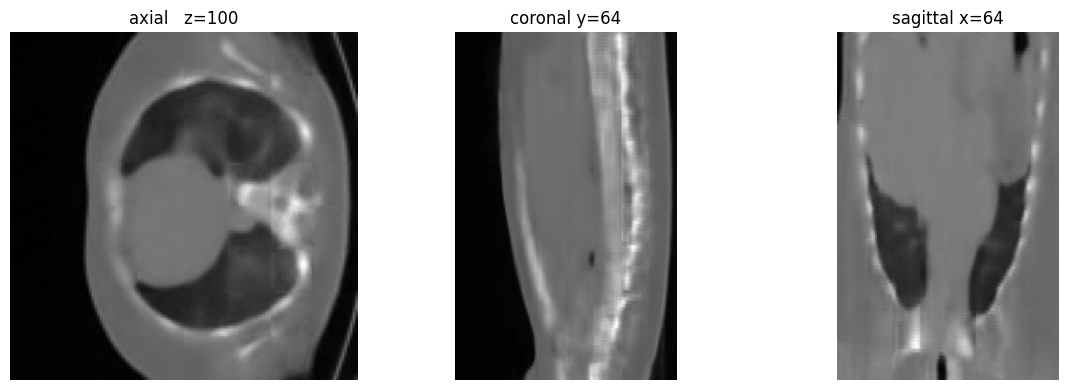

In [3]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

out_dir = Path("/workspace/data/test_generateCT")
out_dir.mkdir(parents=True, exist_ok=True)

vol = volume.squeeze().detach().cpu().numpy()   # (D, H, W)
nib.save(nib.Nifti1Image(vol, np.eye(4)), str(out_dir / "generatect_lowres.nii.gz"))
print("saved:", out_dir / "generatect_lowres.nii.gz", "shape:", vol.shape)

d, h, w = vol.shape
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(vol[d // 2],       cmap="gray"); axes[0].set_title(f"axial   z={d//2}")
axes[1].imshow(vol[:, h // 2],    cmap="gray"); axes[1].set_title(f"coronal y={h//2}")
axes[2].imshow(vol[:, :, w // 2], cmap="gray"); axes[2].set_title(f"sagittal x={w//2}")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

The base dimension of your u-net should ideally be no smaller than 128, as recommended by a professional DDPM trainer https://nonint.com/2022/05/04/friends-dont-let-friends-train-small-diffusion-models/
checkpoint loaded from /workspace/data/checkpoints/generatect/superres_pretrained.pt


0it [00:00, ?it/s]

sampling loop time step:   0%|          | 0/25 [00:00<?, ?it/s]

0it [00:00, ?it/s]

sampling loop time step:   0%|          | 0/25 [00:00<?, ?it/s]

...

0it [00:00, ?it/s]

sampling loop time step:   0%|          | 0/25 [00:00<?, ?it/s]

0it [00:00, ?it/s]

sampling loop time step:   0%|          | 0/25 [00:00<?, ?it/s]

saved: /workspace/data/test_generateCT/generatect_hires.nii.gz shape: (201, 512, 512)


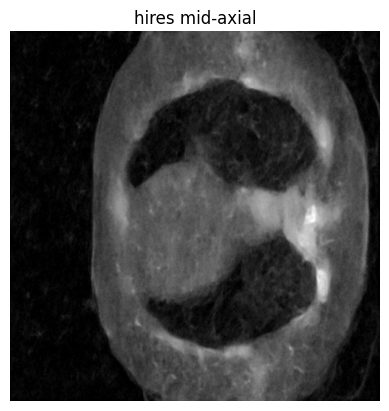

In [4]:
# Super-resolution: 128 -> 512 per frame. Heavier (minutes on A6000). Skip if not needed.
import warnings
warnings.filterwarnings("ignore")

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

out_dir = Path("/workspace/data/test_generateCT")
out_dir.mkdir(parents=True, exist_ok=True)

sr_adapter = GenerateCTAdapter(device_str=DEVICE, load_super_resolution=True)
hires = sr_adapter.inference(prompt, num_frames=201)

vol_hi = hires.squeeze().detach().cpu().numpy()
nib.save(nib.Nifti1Image(vol_hi, np.eye(4)), str(out_dir / "generatect_hires.nii.gz"))
print("saved:", out_dir / "generatect_hires.nii.gz", "shape:", vol_hi.shape)

plt.imshow(vol_hi[vol_hi.shape[0] // 2], cmap="gray")
plt.title("hires mid-axial"); plt.axis("off"); plt.show()

In [ ]:
# --- Clear VRAM (run anytime to free this kernel's GPU memory) ---
# Drops every torch.Tensor / nn.Module in globals, clears IPython Out cache,
# then empty_cache + ipc_collect on every visible GPU.
# Use this instead of restarting the kernel.
from src.utils.gpu import free_gpu_now
free_gpu_now()
